In [2]:
# Cellule 1 — Collecte données dépenses publiques
import wbgapi as wb
import pandas as pd
import numpy as np

# Même liste de pays que le P5
pays = [
    # Afrique francophone
    'SEN', 'CIV', 'CMR', 'MLI', 'BFA', 'MDG', 'TGO',
    # OCDE
    'FRA', 'DEU', 'SWE', 'DNK', 'NOR', 'CAN', 'GBR', 'ITA', 'USA'
]

annees = range(2000, 2025)

# Collecter dépenses santé (% PIB)
print("Collecte dépenses santé...")
df_sante = wb.data.DataFrame(
    'SH.XPD.GHED.GD.ZS',
    economy=pays, time=annees
).reset_index()

# Collecter dépenses éducation (% PIB)
print("Collecte dépenses éducation...")
df_educ = wb.data.DataFrame(
    'SE.XPD.TOTL.GD.ZS',
    economy=pays, time=annees
).reset_index()

print("Santé shape :", df_sante.shape)
print("Éducation shape :", df_educ.shape)
print(df_sante.head(3))

Collecte dépenses santé...
Collecte dépenses éducation...
Santé shape : (16, 26)
Éducation shape : (16, 26)
  economy    YR2000    YR2001    YR2002    YR2003    YR2004    YR2005  \
0     BFA  0.961293  0.971620  1.057990  0.980187  1.699779  1.222853   
1     CAN  6.008865  6.278965  6.415581  6.590530  6.623966  6.598979   
2     CIV  0.586899  0.509783  0.543295  0.515493  0.559932  0.529090   

     YR2006    YR2007    YR2008  ...    YR2015    YR2016    YR2017    YR2018  \
0  1.430978  1.432129  1.361114  ...  1.456188  2.386931  2.687950  2.125235   
1  6.487940  6.574501  6.701127  ...  7.630766  7.727228  7.609263  7.604599   
2  0.557799  0.679661  0.679557  ...  0.804453  0.853021  0.932670  0.898626   

     YR2019    YR2020    YR2021    YR2022    YR2023    YR2024  
0  2.236028  2.845143  2.730583  2.628704  2.452501       NaN  
1  7.682645  9.615358  9.001724  7.867264  7.865524  7.938468  
2  0.963288  1.331831  1.590111  1.490675  1.401238       NaN  

[3 rows x 26 columns]

In [3]:
# Cellule 2 — Nettoyage et fusion
# Mettre en format long (unpivot)
df_sante_long = df_sante.melt(
    id_vars='economy',
    var_name='year',
    value_name='health_exp_pct'
)

df_educ_long = df_educ.melt(
    id_vars='economy',
    var_name='year',
    value_name='educ_exp_pct'
)

# Nettoyer la colonne year : "YR2000" → 2000
df_sante_long['year'] = df_sante_long['year'].str.replace('YR', '').astype(int)
df_educ_long['year'] = df_educ_long['year'].str.replace('YR', '').astype(int)

# Fusionner santé + éducation
df_depenses = df_sante_long.merge(df_educ_long, on=['economy', 'year'], how='left')

# Renommer economy → country_code
df_depenses.rename(columns={'economy': 'country_code'}, inplace=True)

# Charger le dataset fiscal du P5
df_fiscal = pd.read_csv('../data/tax_merged.csv')

# Fusionner avec les données fiscales
df_master = df_fiscal.merge(df_depenses, on=['country_code', 'year'], how='left')

print("Shape final :", df_master.shape)
print("Colonnes :", df_master.columns.tolist())
print(f"Valeurs manquantes santé : {df_master['health_exp_pct'].isna().sum()}")
print(f"Valeurs manquantes éducation : {df_master['educ_exp_pct'].isna().sum()}")

Shape final : (377, 10)
Colonnes : ['country_code', 'country_name', 'year', 'tax_gdp_pct', 'gdp_per_capita', 'life_expectancy', 'groupe', 'log_gdp', 'health_exp_pct', 'educ_exp_pct']
Valeurs manquantes santé : 377
Valeurs manquantes éducation : 377


In [4]:
# Cellule 2b — Diagnostic
print("Codes pays dans df_fiscal :")
print(df_fiscal['country_code'].unique())

print("\nCodes pays dans df_depenses :")
print(df_depenses['country_code'].unique())

Codes pays dans df_fiscal :
['BF' 'CA' 'CI' 'CM' 'DE' 'DK' 'FR' 'GB' 'IT' 'MG' 'ML' 'NO' 'SE' 'SN'
 'TG' 'US']

Codes pays dans df_depenses :
['BFA' 'CAN' 'CIV' 'CMR' 'DEU' 'DNK' 'FRA' 'GBR' 'ITA' 'MDG' 'MLI' 'NOR'
 'SEN' 'SWE' 'TGO' 'USA']


In [5]:
# Diagnostic
print("Codes pays dans df_fiscal :")
print(sorted(df_fiscal['country_code'].unique()))

print("\nCodes pays dans df_depenses :")
print(sorted(df_depenses['country_code'].unique()))

print("\nAnnées dans df_fiscal :", sorted(df_fiscal['year'].unique())[:5])
print("Années dans df_depenses :", sorted(df_depenses['year'].unique())[:5])

Codes pays dans df_fiscal :
['BF', 'CA', 'CI', 'CM', 'DE', 'DK', 'FR', 'GB', 'IT', 'MG', 'ML', 'NO', 'SE', 'SN', 'TG', 'US']

Codes pays dans df_depenses :
['BFA', 'CAN', 'CIV', 'CMR', 'DEU', 'DNK', 'FRA', 'GBR', 'ITA', 'MDG', 'MLI', 'NOR', 'SEN', 'SWE', 'TGO', 'USA']

Années dans df_fiscal : [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004)]
Années dans df_depenses : [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004)]


In [6]:
# Cellule 2c — Corriger les codes pays Solution simple — créer un dictionnaire de correspondance :
iso2_to_iso3 = {
    'BF': 'BFA', 'CA': 'CAN', 'CI': 'CIV', 'CM': 'CMR',
    'DE': 'DEU', 'DK': 'DNK', 'FR': 'FRA', 'GB': 'GBR',
    'IT': 'ITA', 'MG': 'MDG', 'ML': 'MLI', 'NO': 'NOR',
    'SE': 'SWE', 'SN': 'SEN', 'TG': 'TGO', 'US': 'USA'
}

# Convertir df_fiscal vers ISO Alpha-3
df_fiscal['country_code'] = df_fiscal['country_code'].map(iso2_to_iso3)

# Refusionner
df_master = df_fiscal.merge(df_depenses, on=['country_code', 'year'], how='left')

print("Shape :", df_master.shape)
print(f"Valeurs manquantes santé : {df_master['health_exp_pct'].isna().sum()}")
print(f"Valeurs manquantes éducation : {df_master['educ_exp_pct'].isna().sum()}")

Shape : (377, 10)
Valeurs manquantes santé : 12
Valeurs manquantes éducation : 82


In [8]:
# Cellule 3 — Indice qualité des dépenses publiques
# Interpolation pour combler les valeurs manquantes
df_master = df_master.sort_values(['country_code', 'year'])

df_master['health_exp_pct'] = df_master.groupby('country_code')['health_exp_pct']\
    .transform(lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill'))

df_master['educ_exp_pct'] = df_master.groupby('country_code')['educ_exp_pct']\
    .transform(lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill'))

# Créer l'indice social = santé + éducation (% PIB)
df_master['indice_social'] = df_master['health_exp_pct'] + df_master['educ_exp_pct']

# Créer catégorie haute/basse dépense sociale par groupe
df_master['qualite_depense'] = df_master.groupby('groupe')['indice_social']\
    .transform(lambda x: pd.qcut(x, q=2, labels=['Faible', 'Élevée']))

print("Valeurs manquantes après interpolation :")
print(df_master[['health_exp_pct', 'educ_exp_pct', 'indice_social']].isna().sum())
print("\nStatistiques indice social par groupe :")
print(df_master.groupby('groupe')['indice_social'].describe().round(2))

Valeurs manquantes après interpolation :
health_exp_pct    0
educ_exp_pct      0
indice_social     0
dtype: int64

Statistiques indice social par groupe :
                     count   mean   std   min    25%    50%    75%    max
groupe                                                                   
Afrique francophone  152.0   4.59  1.29  2.65   3.70   4.27   5.10   8.32
OCDE                 225.0  13.46  1.94  9.44  12.13  13.22  14.87  18.19


C:\Users\user\AppData\Local\Temp\ipykernel_44084\3530347532.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .transform(lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill'))
C:\Users\user\AppData\Local\Temp\ipykernel_44084\3530347532.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .transform(lambda x: x.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill'))


In [9]:
# Cellule 3b — Version sans warnings
df_master['health_exp_pct'] = df_master.groupby('country_code')['health_exp_pct']\
    .transform(lambda x: x.interpolate(method='linear').bfill().ffill())

df_master['educ_exp_pct'] = df_master.groupby('country_code')['educ_exp_pct']\
    .transform(lambda x: x.interpolate(method='linear').bfill().ffill())

print("✅ Interpolation sans warnings")

✅ Interpolation sans warnings


In [10]:
# Cellule 4 — Régression enrichie avec indice social
import statsmodels.api as sm

# Préparer les données
cols_needed = ['life_expectancy', 'tax_gdp_pct', 'gdp_per_capita', 
               'groupe', 'indice_social', 'health_exp_pct', 'educ_exp_pct']
df_reg2 = df_master[cols_needed].dropna().copy()

df_reg2['log_gdp'] = np.log(df_reg2['gdp_per_capita'])

# Encoder groupe
df_reg2 = pd.get_dummies(df_reg2, columns=['groupe'], drop_first=True, dtype=int)

print(f"Observations : {len(df_reg2)}")

# Modèle enrichi — avec indice social
y = df_reg2['life_expectancy']
dummy_cols = [c for c in df_reg2.columns if c.startswith('groupe_')]

X = df_reg2[['tax_gdp_pct', 'log_gdp', 'indice_social'] + dummy_cols]
X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()
print(model2.summary())

Observations : 377
                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     1349.
Date:                Mon, 04 May 2026   Prob (F-statistic):          6.88e-220
Time:                        20:26:43   Log-Likelihood:                -922.45
No. Observations:                 377   AIC:                             1855.
Df Residuals:                     372   BIC:                             1875.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            46.8628   

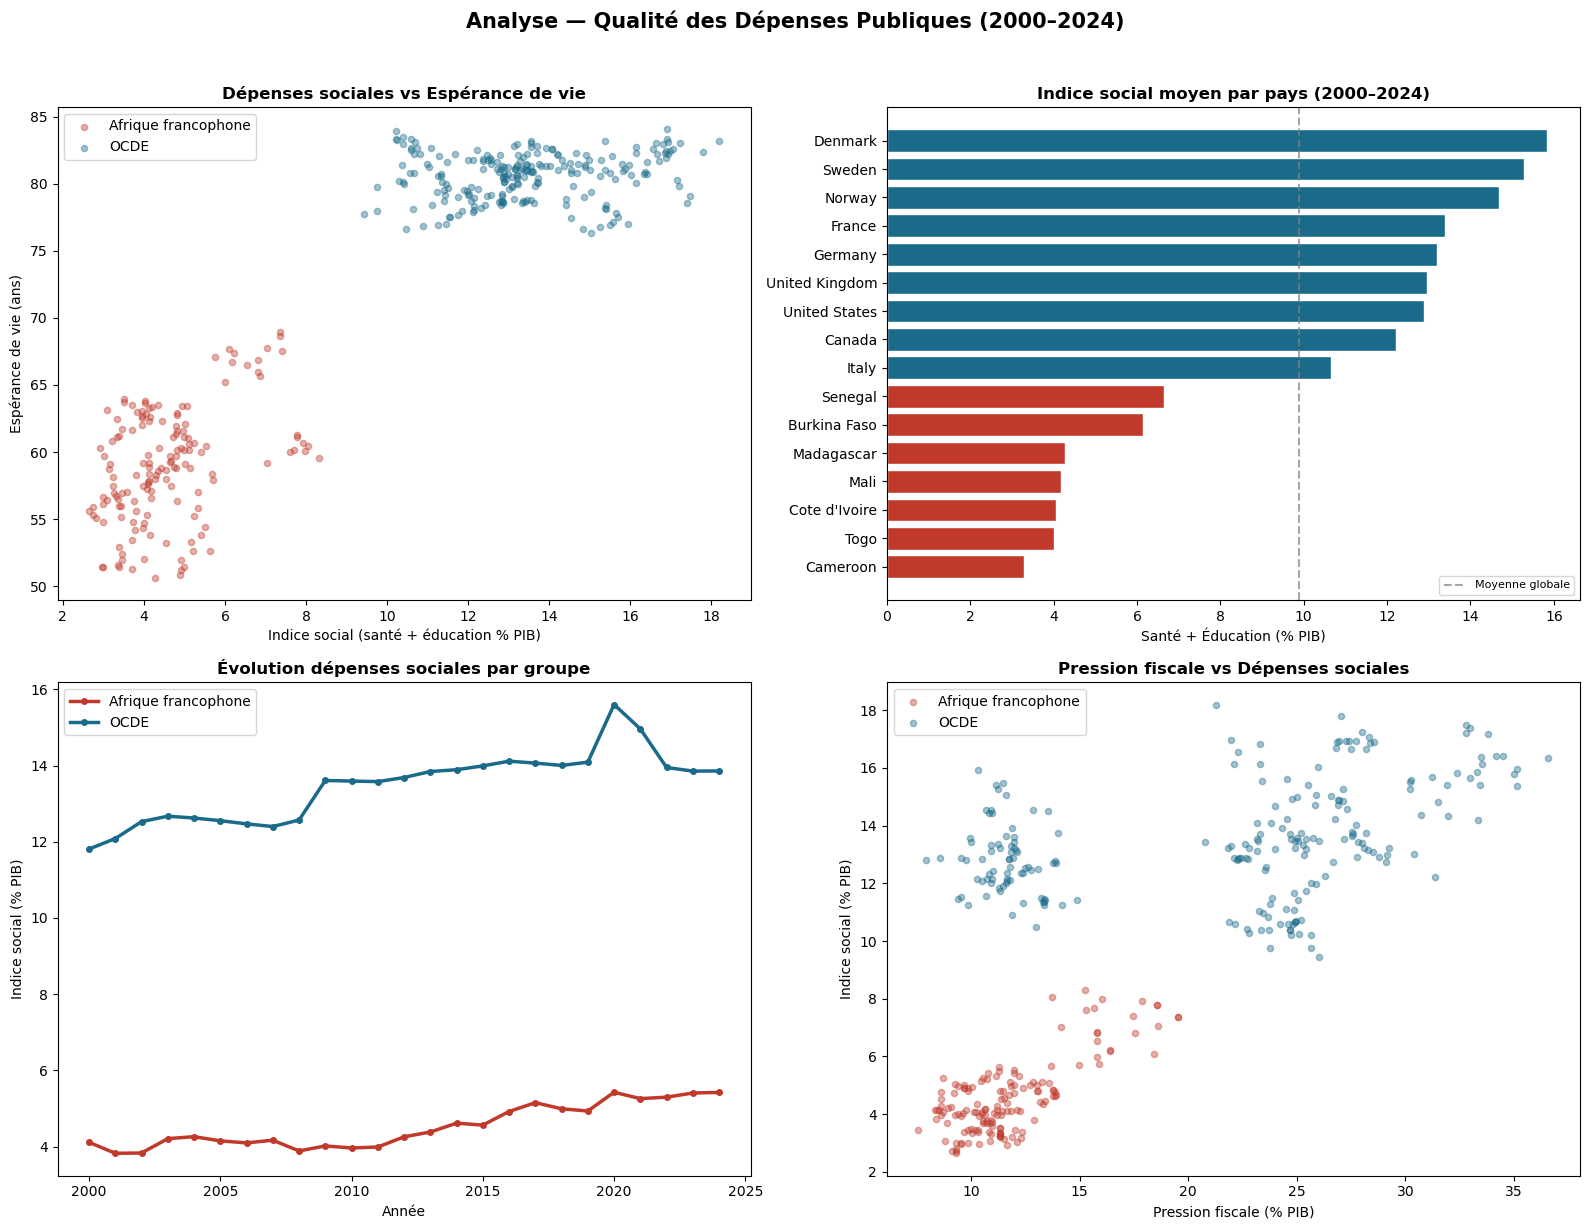

Graphique sauvegardé !


In [12]:
# Cellule 5 — Visualisations qualité des dépenses publiques
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = {'Afrique francophone': '#C0392B', 'OCDE': '#1A6B8A'}

# 1. Scatter : indice social vs espérance de vie
for groupe, color in colors.items():
    data = df_master[df_master['groupe'] == groupe]
    axes[0,0].scatter(data['indice_social'], data['life_expectancy'],
                     c=color, alpha=0.4, s=20, label=groupe)
axes[0,0].set_title('Dépenses sociales vs Espérance de vie', fontweight='bold')
axes[0,0].set_xlabel('Indice social (santé + éducation % PIB)')
axes[0,0].set_ylabel('Espérance de vie (ans)')
axes[0,0].legend()

# 2. Bar chart : indice social moyen par pays
df_pays = df_master.groupby(['country_name', 'groupe'])[['indice_social']]\
    .mean().sort_values('indice_social').reset_index()
colors_bar = df_pays['groupe'].map(colors)
axes[0,1].barh(df_pays['country_name'], df_pays['indice_social'],
               color=colors_bar, edgecolor='white')
axes[0,1].set_title('Indice social moyen par pays (2000–2024)', fontweight='bold')
axes[0,1].set_xlabel('Santé + Éducation (% PIB)')
axes[0,1].axvline(x=df_master['indice_social'].mean(), color='gray',
                  linestyle='--', alpha=0.7, label='Moyenne globale')
axes[0,1].legend(fontsize=8)

# 3. Évolution temporelle indice social par groupe
df_time = df_master.groupby(['year', 'groupe'])['indice_social'].mean().reset_index()
for groupe, color in colors.items():
    data = df_time[df_time['groupe'] == groupe]
    axes[1,0].plot(data['year'], data['indice_social'],
                  label=groupe, color=color, linewidth=2.5, marker='o', markersize=4)
axes[1,0].set_title('Évolution dépenses sociales par groupe', fontweight='bold')
axes[1,0].set_xlabel('Année')
axes[1,0].set_ylabel('Indice social (% PIB)')
axes[1,0].legend()

# 4. Scatter : pression fiscale vs indice social
for groupe, color in colors.items():
    data = df_master[df_master['groupe'] == groupe]
    axes[1,1].scatter(data['tax_gdp_pct'], data['indice_social'],
                     c=color, alpha=0.4, s=20, label=groupe)
axes[1,1].set_title('Pression fiscale vs Dépenses sociales', fontweight='bold')
axes[1,1].set_xlabel('Pression fiscale (% PIB)')
axes[1,1].set_ylabel('Indice social (% PIB)')
axes[1,1].legend()

plt.suptitle('Analyse — Qualité des Dépenses Publiques (2000–2024)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_depenses_publiques.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

In [14]:
# Cellule 6 — Export du dataset enrichi
df_master.to_csv('../data/fiscal_social_master.csv', index=False, encoding='utf-8-sig')

print("Export OK !")
print(f"Colonnes : {df_master.columns.tolist()}")
print(f"Shape : {df_master.shape}")

Export OK !
Colonnes : ['country_code', 'country_name', 'year', 'tax_gdp_pct', 'gdp_per_capita', 'life_expectancy', 'groupe', 'log_gdp', 'health_exp_pct', 'educ_exp_pct', 'indice_social', 'qualite_depense']
Shape : (377, 12)
